In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df_types = pd.read_csv("transaction_types.csv")
df_txn = pd.read_csv("transactions_data_training.csv")
df_profile = pd.read_csv("user_profile.csv")
df_mcc = pd.read_csv("mcc_group_definition.csv")

In [3]:
df_txn.head()

,user_id,transaction_date,transaction_type,mcc_group,amount_n26_currency,dataset_transaction,dataset_user
0,a78884f5e76951188c1e719d4956773a,2016-02-01,DT,NaN,350,training,training
1,b0333294fef6ff1299102a70ad46b126,2016-02-01,DT,NaN,202,training,training
2,7b8d2a2780adae0cd0c248e92c1b28dc,2016-02-01,DT,NaN,291,training,training
3,cc4abaa500f7db4390ae3f02bd36d805,2016-02-01,DT,NaN,214,training,training
4,49b99d1d5ba028566639e8b3eb7c055b,2016-02-01,DT,NaN,272,training,training


In [4]:
df_mcc.head()

,mcc_group,explanation
0,1,ATM
1,2,Groceries
2,3,Gastronomie
3,4,Shopping/(Fashion)
4,5,"Home and DIY, House Energy"


In [5]:
df_profile.head()

,user_id,age,age_band,country,city_tier,employment_status,industry,income_band,account_tenure_days
0,000295594379774ab9ac2c78c946d615,47,45-54,DE,2,self_employed,healthcare,50-75k,119
1,000aa792d73dd82b16a29692772d395a,61,55+,AT,1,employed_ft,finance,50-75k,134
2,0011103fe4ba1264342882b7ab98c641,58,55+,FR,1,retired,other,50-75k,109
3,001679c77c33d7efabf800596fb2a978,53,45-54,DE,2,self_employed,education,50-75k,127
4,001e72a2f4c4376f10011735dde39cd5,28,25-34,IE,2,employed_ft,healthcare,30-50k,94


In [6]:
df_types.head()

,type,explanation,direction,agent
0,AR,Authorization reject,-,Card
1,AE,Authorization expired,In,Card
2,AV,Authorization Reversal,In,Card
3,BBU,Cash26 deposit,In,Partner
4,CT,Credit Transfer,In,Bank Account


In [7]:
df_txn.dtypes

user_id                    str
transaction_date           str
transaction_type           str
mcc_group              float64
amount_n26_currency      int64
dataset_transaction        str
dataset_user               str
dtype: object

In [8]:
df_txn["transaction_date"] = pd.to_datetime(df_txn["transaction_date"])

In [9]:
df_txn.dtypes

user_id                           str
transaction_date       datetime64[us]
transaction_type                  str
mcc_group                     float64
amount_n26_currency             int64
dataset_transaction               str
dataset_user                      str
dtype: object

In [10]:
print(f"Total transaction :" ,df_txn.shape[0], 
      f", User :", df_txn["user_id"].nunique())

Total transaction : 408546 , User : 10000


In [11]:
df_profile.shape

(9470, 9)

In [12]:
direction_map = (
    df_types.set_index("type")["direction"].to_dict()
)

In [13]:
direction_map

{'AR': '-',
 'AE': 'In',
 'AV': 'In',
 'BBU': 'In',
 'CT': 'In',
 'DI': 'In',
 'DR': 'In',
 'PF': 'In',
 'PR': 'In',
 'WU': 'In',
 'AA': 'Out',
 'BUB': 'Out',
 'DD': 'Out',
 'DT': 'Out',
 'FT': 'Out',
 'PT': 'Out',
 'TUB': 'Out',
 'TBU': 'In',
 'WEE': 'Out',
 'AL': 'In',
 'AU': 'Out',
 'BUS': 'Out',
 'BRU': 'Out'}

In [14]:
df_txn["direction"] = df_txn["transaction_type"].map(direction_map)

In [15]:
df_txn.head()

,user_id,transaction_date,transaction_type,mcc_group,amount_n26_currency,dataset_transaction,dataset_user,direction
0,a78884f5e76951188c1e719d4956773a,2016-02-01,DT,NaN,350,training,training,Out
1,b0333294fef6ff1299102a70ad46b126,2016-02-01,DT,NaN,202,training,training,Out
2,7b8d2a2780adae0cd0c248e92c1b28dc,2016-02-01,DT,NaN,291,training,training,Out
3,cc4abaa500f7db4390ae3f02bd36d805,2016-02-01,DT,NaN,214,training,training,Out
4,49b99d1d5ba028566639e8b3eb7c055b,2016-02-01,DT,NaN,272,training,training,Out


In [16]:
df_txn["direction"].isna().sum()

np.int64(0)

In [17]:
df_txn['direction'].value_counts()

direction
Out    336421
In      72125
Name: count, dtype: int64

In [18]:
assert (df_txn['amount_n26_currency'] > 0).all()

In [19]:
df_txn["mcc_group"].isna().sum()

np.int64(150222)

In [20]:
df_profile.columns

Index(['user_id', 'age', 'age_band', 'country', 'city_tier',
       'employment_status', 'industry', 'income_band', 'account_tenure_days'],
      dtype='str')

In [21]:
df_profile_clean = df_profile.drop(
    columns = ["age", "account_tenure_days"]
)

In [22]:
df_profile_clean.head()

,user_id,age_band,country,city_tier,employment_status,industry,income_band
0,000295594379774ab9ac2c78c946d615,45-54,DE,2,self_employed,healthcare,50-75k
1,000aa792d73dd82b16a29692772d395a,55+,AT,1,employed_ft,finance,50-75k
2,0011103fe4ba1264342882b7ab98c641,55+,FR,1,retired,other,50-75k
3,001679c77c33d7efabf800596fb2a978,45-54,DE,2,self_employed,education,50-75k
4,001e72a2f4c4376f10011735dde39cd5,25-34,IE,2,employed_ft,healthcare,30-50k


In [23]:
df_txn['transaction_date'].min(), df_txn['transaction_date'].max()


(Timestamp('2016-02-01 00:00:00'), Timestamp('2016-07-31 00:00:00'))

In [24]:
train_start = "2016-02-01"
train_end ="2016-05-31"
target_start = "2016-06-01"
target_end = "2016-07-31"

In [25]:
df_train_txn = df_txn[(df_txn["transaction_date"] >= train_start) & (df_txn["transaction_date"] <= train_end)]
df_target_txn = df_txn[(df_txn["transaction_date"] >= target_start) & (df_txn["transaction_date"] <= target_end)]


In [26]:
print(
    f"Feature window: {len(df_train_txn):,} txns "
    f"({train_start} to {train_end})"
)
print(
    f"Target window:  {len(df_target_txn):,} txns "
    f"({target_start} to {target_end})"
)

Feature window: 267,593 txns (2016-02-01 to 2016-05-31)
Target window:  140,953 txns (2016-06-01 to 2016-07-31)


In [27]:
df_train_txn.head()

,user_id,transaction_date,transaction_type,mcc_group,amount_n26_currency,dataset_transaction,dataset_user,direction
0,a78884f5e76951188c1e719d4956773a,2016-02-01,DT,NaN,350,training,training,Out
1,b0333294fef6ff1299102a70ad46b126,2016-02-01,DT,NaN,202,training,training,Out
2,7b8d2a2780adae0cd0c248e92c1b28dc,2016-02-01,DT,NaN,291,training,training,Out
3,cc4abaa500f7db4390ae3f02bd36d805,2016-02-01,DT,NaN,214,training,training,Out
4,49b99d1d5ba028566639e8b3eb7c055b,2016-02-01,DT,NaN,272,training,training,Out


In [28]:
model_users = sorted(
    df_train_txn["user_id"].unique()
)

In [30]:
target_in = (
    df_target_txn[df_target_txn["direction"] == "In"].groupby("user_id")["amount_n26_currency"].sum()
)

target_out = (
    df_target_txn[df_target_txn["direction"] == "Out"].groupby("user_id")["amount_n26_currency"].sum()
)

In [31]:
target_in.head()

user_id
000295594379774ab9ac2c78c946d615     115
000aa792d73dd82b16a29692772d395a     155
0011103fe4ba1264342882b7ab98c641    1578
001679c77c33d7efabf800596fb2a978    2280
001f9baedaf3c8487c344d25b0eda9fc      52
Name: amount_n26_currency, dtype: int64

In [32]:
targets = pd.DataFrame(index = model_users)
targets.index.name = "user_id"
targets['total_income'] = (
    target_in.reindex(model_users).fillna(0)
)

targets['total_expenses'] = (
    target_out.reindex(model_users).fillna(0)
)

n_churn = (
    (targets['total_income'] == 0)
    & (targets['total_expenses'] == 0)
).sum()

print(
    f"Population: {len(model_users):,} users "
    f"({n_churn:,} churned = target 0)"
)
print(targets.describe().to_string())


Population: 9,470 users (1,642 churned = target 0)


       total_income  total_expenses
count   9470.000000     9470.000000
mean     352.091658      425.058289
std      570.404906      778.001201
min        0.000000        0.000000
25%        0.000000       13.000000
50%      112.000000      136.000000
75%      465.000000      521.000000
max     7820.000000    14603.000000


In [33]:
targets

,total_income,total_expenses
user_id,,
000295594379774ab9ac2c78c946d615,115.0,77.0
000aa792d73dd82b16a29692772d395a,155.0,228.0
0011103fe4ba1264342882b7ab98c641,1578.0,1103.0
001679c77c33d7efabf800596fb2a978,2280.0,2817.0
001e72a2f4c4376f10011735dde39cd5,0.0,0.0
...,...,...
fff571276eaa49853039f6bfe1102fba,55.0,32.0
fff6ea4b3659a969c62c17c1d1655394,0.0,22.0
fff9eec15875baad3df433c8780aa3bd,23.0,167.0


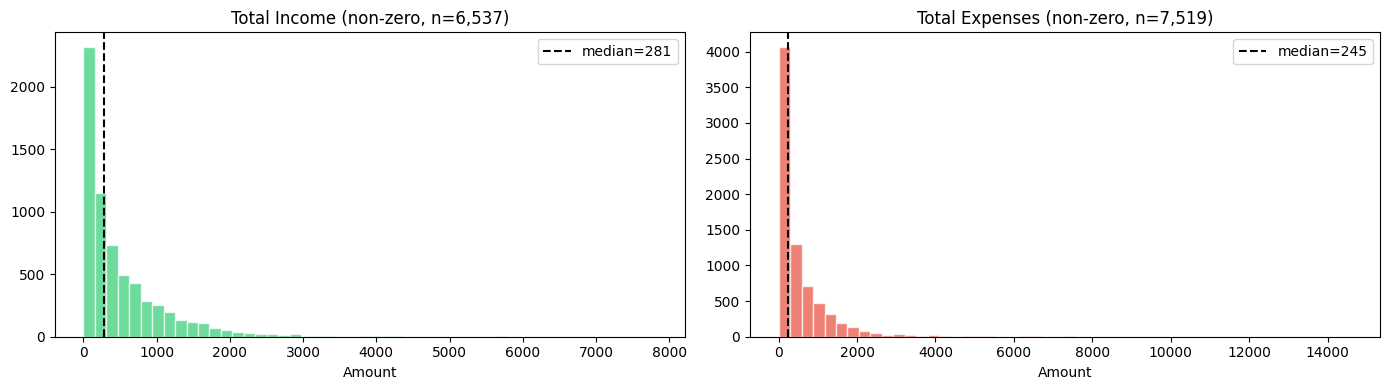

In [35]:
fig_targets, _axs_tgt = plt.subplots(
    1, 2, figsize=(14, 4),
)

for _i, (_col, _color) in enumerate([
    ('total_income', '#2ecc71'),
    ('total_expenses', '#e74c3c'),
]):
    _ax = _axs_tgt[_i]
    _vals = targets[_col]
    _nz = _vals[_vals > 0]
    _ax.hist(
        _nz, bins=50, color=_color, alpha=0.7,
        edgecolor='white',
    )
    _ax.set_title(
        f'{_col.replace("_", " ").title()} '
        f'(non-zero, n={len(_nz):,})'
    )
    _ax.set_xlabel('Amount')
    _ax.axvline(
        _nz.median(), color='black',
        ls='--', label=f'median={_nz.median():.0f}',
    )
    _ax.legend()
plt.tight_layout()
plt.show()

### Feature Engineering

In [ ]:
def engineer_transaction_features(df_feat, user_ids):
    '''
    Create user-level features from FEATURE WINDOW
    transactions only. Five feature groups:
    1. Counts (volume of activity)
    2. Amounts (spending/income levels)
    3. MCC categories (what they spend on)
    4. Temporal (when and how often)
    5. Behavioural (spending patterns and trends)
    '''
    features = pd.DataFrame(index=user_ids)
    features.index.name = 'user_id'

    features['n_transactions'] = (
        df_feat.groupby('user_id').size()
    )
    dir_counts = (
        df_feat.groupby(['user_id', 'direction']).size().unstack(fill_value=0)
    )
    for d in ['In', 'Out']:
        features[f'n_txn_{d.lower()}'] = (
            dir_counts.get(d, 0)
        )
    type_counts = (
        df_feat
        .groupby(['user_id', 'transaction_type'])
        .size().unstack(fill_value=0)
    )
    for tt in type_counts.columns:
        features[f'n_type_{tt}'] = type_counts[tt]

    for direction in ['In', 'Out']:
        subset = df_feat[
            df_feat['direction'] == direction
        ]
        grp = subset.groupby('user_id')[
            'amount_n26_currency'
        ]
        d = direction.lower()
        features[f'amount_{d}_sum'] = grp.sum()
        features[f'amount_{d}_mean'] = grp.mean()
        features[f'amount_{d}_median'] = grp.median()
        features[f'amount_{d}_std'] = grp.std()
        features[f'amount_{d}_max'] = grp.max()

    mcc_valid = df_feat[df_feat['mcc_group'].notna()]
    if len(mcc_valid) > 0:
        mcc_counts = (
            mcc_valid
            .groupby(['user_id', 'mcc_group'])
            .size().unstack(fill_value=0)
        )
        for mcc in mcc_counts.columns:
            features[f'mcc_{int(mcc)}'] = (
                mcc_counts[mcc]
            )
        features['n_mcc_categories'] = (
            mcc_valid
            .groupby('user_id')['mcc_group']
            .nunique()
        )
        features['dominant_mcc'] = (
            mcc_valid
            .groupby('user_id')['mcc_group']
            .agg(lambda x: x.mode().min())
            .astype(int).astype(str)
        )

    date_stats = (
        df_feat
        .groupby('user_id')['transaction_date']
        .agg(['min', 'max', 'count'])
    )
    features['activity_span_days'] = (
        (date_stats['max'] - date_stats['min'])
        .dt.days
    )
    features['txn_per_day'] = (
        features['n_transactions']
        / (features['activity_span_days'] + 1)
    )
    df_fc = df_feat.copy()
    df_fc['month'] = (
        df_fc['transaction_date'].dt.month
    )
    features['n_active_months'] = (
        df_fc.groupby('user_id')['month'].nunique()
    )

    features['in_out_ratio'] = (
        features['n_txn_in']
        / (features['n_txn_out'] + 1)
    )
    features['pct_card_txns'] = (
        features['n_type_PT']
        if 'n_type_PT' in features.columns
        else 0
    ) / (features['n_transactions'] + 1)

    df_fc['is_weekend'] = (
        df_fc['transaction_date'].dt.dayofweek >= 5
    )
    features['weekend_ratio'] = (
        df_fc.groupby('user_id')['is_weekend'].mean()
    )

    out_monthly = (
        df_feat[df_feat['direction'] == 'Out']
        .copy()
    )
    out_monthly['month_num'] = (
        out_monthly['transaction_date'].dt.month
    )
    monthly_totals = (
        out_monthly
        .groupby(['user_id', 'month_num'])
        ['amount_n26_currency'].sum()
        .reset_index()
    )

    def _slope(g):
        if len(g) < 3:
            return 0.0
        x = g['month_num'].values.astype(float)
        y = g['amount_n26_currency'].values.astype(
            float
        )
        return np.polyfit(x, y, 1)[0]

    features['spending_slope'] = (
        monthly_totals.groupby('user_id')
        .apply(_slope)
    )

    out_amt = (
        df_feat[df_feat['direction'] == 'Out']
        .groupby('user_id')['amount_n26_currency']
    )
    features['txn_size_cv'] = (
        out_amt.std() / (out_amt.mean() + 1)
    )

    if 'dominant_mcc' in features.columns:
        features['dominant_mcc'] = (
            features['dominant_mcc'].fillna('unknown')
        )
    features = features.fillna(0)
    return features

In [37]:
txn_features = engineer_transaction_features(
    df_train_txn, model_users,
)
df_model = (
    txn_features.reset_index()
    .merge(df_profile_clean, on='user_id', how='left')
    .merge(
        targets.reset_index(), on='user_id', how='left',
    )
)
print(
    f"Modelling DataFrame: {df_model.shape[0]} users "
    f"× {df_model.shape[1]} columns"
)

Modelling DataFrame: 9470 users × 58 columns


In [38]:
categorical_features = [
    'age_band', 'country', 'city_tier',
    'employment_status', 'industry', 'income_band',
    'dominant_mcc',
]
categorical_features_income = [
    f for f in categorical_features
    if f != 'income_band'
]
categorical_features_expenses = list(
    categorical_features
)

target_names = ['total_income', 'total_expenses']
numeric_features = [
    c for c in
    df_model.select_dtypes(include=[np.number]).columns
    if c not in target_names
    and c not in ['city_tier']
]

all_features = (
    numeric_features + categorical_features
)
print(
    f"Features: {len(numeric_features)} numeric "
    f"+ {len(categorical_features)} categorical"
)

Features: 48 numeric + 7 categorical


In [43]:

from sklearn.model_selection import train_test_split


X = df_model.set_index('user_id')[all_features].copy()
y_income = df_model.set_index('user_id')['total_income']
y_expenses = df_model.set_index('user_id')['total_expenses']

(
    X_train, X_temp,
    y_inc_train, y_inc_temp,
    y_exp_train, y_exp_temp,
) = train_test_split(
    X, y_income, y_expenses,
    test_size=0.30, random_state=42,
)
(
    X_val, X_test,
    y_inc_val, y_inc_test,
    y_exp_val, y_exp_test,
) = train_test_split(
    X_temp, y_inc_temp, y_exp_temp,
    test_size=0.50, random_state=42,
)
X_trainval = pd.concat([X_train, X_val])
y_inc_trainval = pd.concat([y_inc_train, y_inc_val])
y_exp_trainval = pd.concat([y_exp_train, y_exp_val])

assert set(X_train.index).isdisjoint(set(X_test.index))
print(
    f"Train: {len(X_train):,} / "
    f"Val: {len(X_val):,} / "
    f"Test: {len(X_test):,}"
)

Train: 6,629 / Val: 1,420 / Test: 1,421


In [44]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_preprocessor(cat_feats):
    return ColumnTransformer(
        transformers=[
            (
                'num', StandardScaler(),
                numeric_features,
            ),
            (
                'cat',
                OneHotEncoder(
                    drop='first',
                    handle_unknown='infrequent_if_exist',
                    min_frequency=10,
                ),
                cat_feats,
            ),
        ],
        remainder='drop',
    )

def build_pipeline(model, target='expenses'):
    cat = (
        categorical_features_income
        if target == 'income'
        else categorical_features_expenses
    )
    return Pipeline([
        ('preprocess', make_preprocessor(cat)),
        ('model', clone(model)),
    ])

In [45]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


models = {
    'Baseline (Mean)': DummyRegressor(strategy='mean'),
    'Baseline (Median)': DummyRegressor(strategy='median'),
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
}

def evaluate_model(
    pipeline, X_tr, y_tr, X_v, y_v,
    use_log=True,
):
    y_fit = np.log1p(y_tr) if use_log else y_tr
    pipeline.fit(X_tr, y_fit)
    y_pred_raw = pipeline.predict(X_v)

    if use_log:
        y_pred = np.maximum(np.expm1(y_pred_raw), 0)
    else:
        y_pred = y_pred_raw

    return {
        'val_mae': mean_absolute_error(y_v, y_pred),
        'val_rmse': np.sqrt(mean_squared_error(y_v, y_pred)),
        'val_r2': r2_score(y_v, y_pred),
        'pipeline': pipeline,
        'use_log': use_log,
    }

In [46]:
results = {}
for _tgt_name, _y_tr, _y_val in [
    ('income', y_inc_train, y_inc_val),
    ('expenses', y_exp_train, y_exp_val),
]:
    results[_tgt_name] = {}
    print(
        f"\n{'─'*40}\n"
        f"  Target: {_tgt_name}\n"
        f"{'─'*40}"
    )
    for _model_name, _model in models.items():
        _pipe = build_pipeline(
            _model, target=_tgt_name,
        )
        _res = evaluate_model(
            _pipe, X_train, _y_tr, X_val, _y_val,
            use_log=True,
        )
        results[_tgt_name][_model_name] = _res
        print(
            f"  {_model_name:22s}  "
            f"MAE={_res['val_mae']:8.1f}  "
            f"R²={_res['val_r2']:+.3f}"
        )


────────────────────────────────────────
  Target: income
────────────────────────────────────────
  Baseline (Mean)         MAE=   343.6  R²=-0.287
  Baseline (Median)       MAE=   337.0  R²=-0.174
  Linear Regression       MAE=   337.4  R²=-5.949
  Ridge                   MAE=   337.2  R²=-5.964
  Lasso                   MAE=   333.9  R²=-0.247
  ElasticNet              MAE=   315.6  R²=-0.129
  Decision Tree           MAE=   251.5  R²=+0.251
  Random Forest           MAE=   231.5  R²=+0.307
  Gradient Boosting       MAE=   236.6  R²=+0.281

────────────────────────────────────────
  Target: expenses
────────────────────────────────────────
  Baseline (Mean)         MAE=   378.2  R²=-0.196
  Baseline (Median)       MAE=   372.4  R²=-0.126
  Linear Regression       MAE=   283.9  R²=-0.504
  Ridge                   MAE=   283.8  R²=-0.495
  Lasso                   MAE=   357.9  R²=-0.137
  ElasticNet              MAE=   322.3  R²=+0.043
  Decision Tree           MAE=   238.2  R²=+0.45

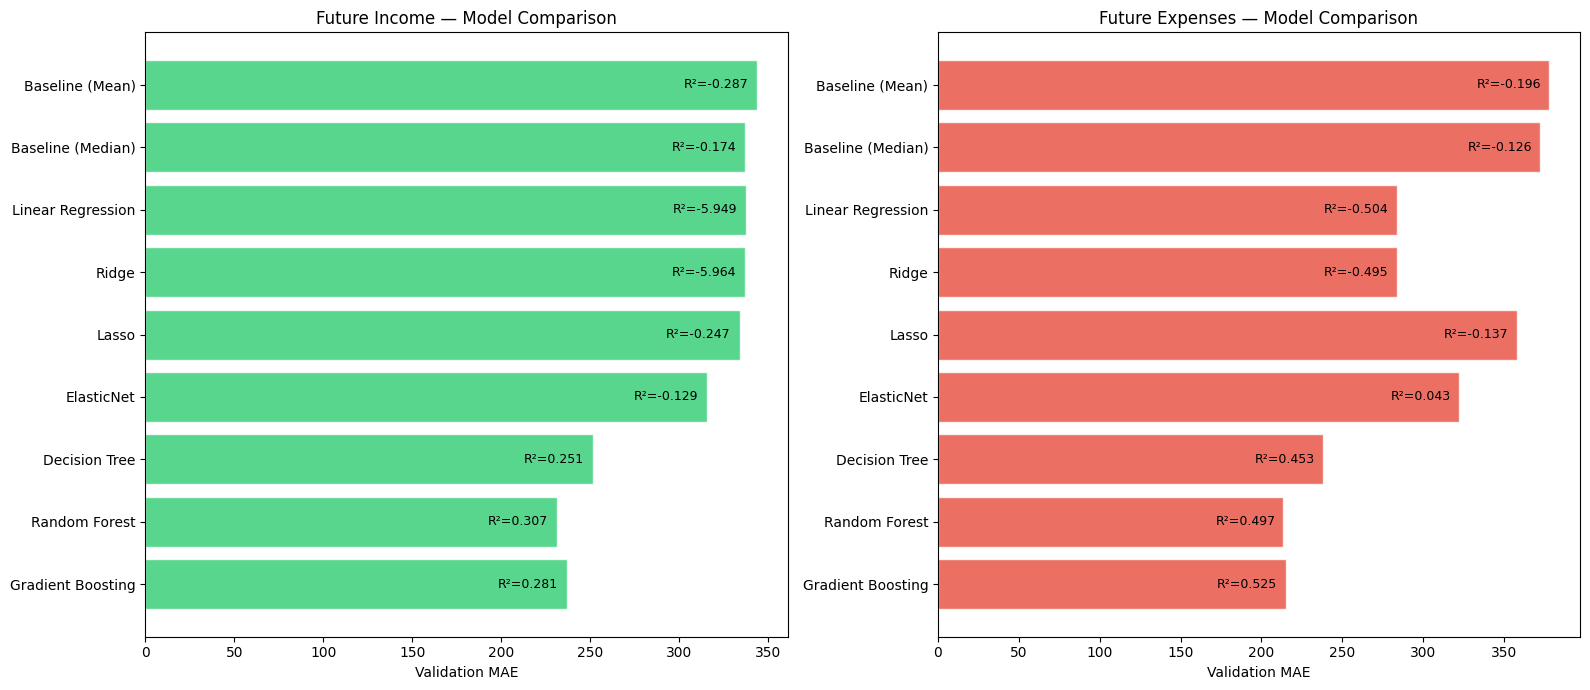

In [47]:
# Model comparison chart
fig_model_cmp, ax_model_cmp = plt.subplots(
    1, 2, figsize=(16, 7),
)

for _i, _tgt_cmp in enumerate(['income', 'expenses']):
    _names_cmp = list(results[_tgt_cmp].keys())
    _maes_cmp = [
        results[_tgt_cmp][m]['val_mae']
        for m in _names_cmp
    ]
    _r2s_cmp = [
        results[_tgt_cmp][m]['val_r2']
        for m in _names_cmp
    ]

    _color = (
        '#2ecc71' if _tgt_cmp == 'income'
        else '#e74c3c'
    )
    _ax = ax_model_cmp[_i]
    _bars = _ax.barh(
        _names_cmp, _maes_cmp,
        color=_color, alpha=0.8, edgecolor='white',
    )
    _ax.set_xlabel('Validation MAE')
    _ax.set_title(
        f'Future {_tgt_cmp.title()} — '
        f'Model Comparison'
    )
    _ax.invert_yaxis()

    for _bar, _r2_v in zip(_bars, _r2s_cmp):
        _ax.text(
            _bar.get_width() - 5,
            _bar.get_y() + _bar.get_height() / 2,
            f'R²={_r2_v:.3f}',
            va='center', ha='right',
            fontsize=9, fontweight='normal',
            color='black',
        )

plt.tight_layout()
plt.show()

In [48]:
best_models = {}
for _target in ['income', 'expenses']:
    _real = {
        k: v for k, v in results[_target].items()
        if 'Baseline' not in k
    }
    _best_name = min(
        _real, key=lambda m: _real[m]['val_mae'],
    )
    best_models[_target] = {
        'name': _best_name,
        **_real[_best_name],
    }

    _baseline = results[_target]['Baseline (Mean)']
    _lift = (
        (_baseline['val_mae']
         - _real[_best_name]['val_mae'])
        / _baseline['val_mae'] * 100
    )
    print(
        f"{_target}: {_best_name} "
        f"(MAE={_real[_best_name]['val_mae']:.1f}, "
        f"{_lift:.0f}% lift over mean baseline)"
    )
    

income: Random Forest (MAE=231.5, 33% lift over mean baseline)
expenses: Random Forest (MAE=213.7, 43% lift over mean baseline)


In [49]:
test_results = {}
for _target, _y_tv, _y_te in [
    ('income', y_inc_trainval, y_inc_test),
    ('expenses', y_exp_trainval, y_exp_test),
]:
    best = best_models[_target]
    _model = best['pipeline'].named_steps['model']
    _fresh = build_pipeline(
        type(_model)(**_model.get_params()),
        target=_target,
    )

    if best['use_log']:
        _fresh.fit(X_trainval, np.log1p(_y_tv))
        _pred = np.maximum(
            np.expm1(_fresh.predict(X_test)), 0,
        )
    else:
        _fresh.fit(X_trainval, _y_tv)
        _pred = _fresh.predict(X_test)

    _mae = mean_absolute_error(_y_te, _pred)
    _r2 = r2_score(_y_te, _pred)
    test_results[_target] = {
        'pipeline': _fresh,
        'y_pred': _pred,
        'y_true': _y_te,
        'mae': _mae, 'r2': _r2,
    }
    print(
        f"{_target}: MAE={_mae:.1f}, R²={_r2:.4f} "
        f"({best['name']})"
    )

income: MAE=228.5, R²=0.3411 (Random Forest)
expenses: MAE=236.1, R²=0.4227 (Random Forest)


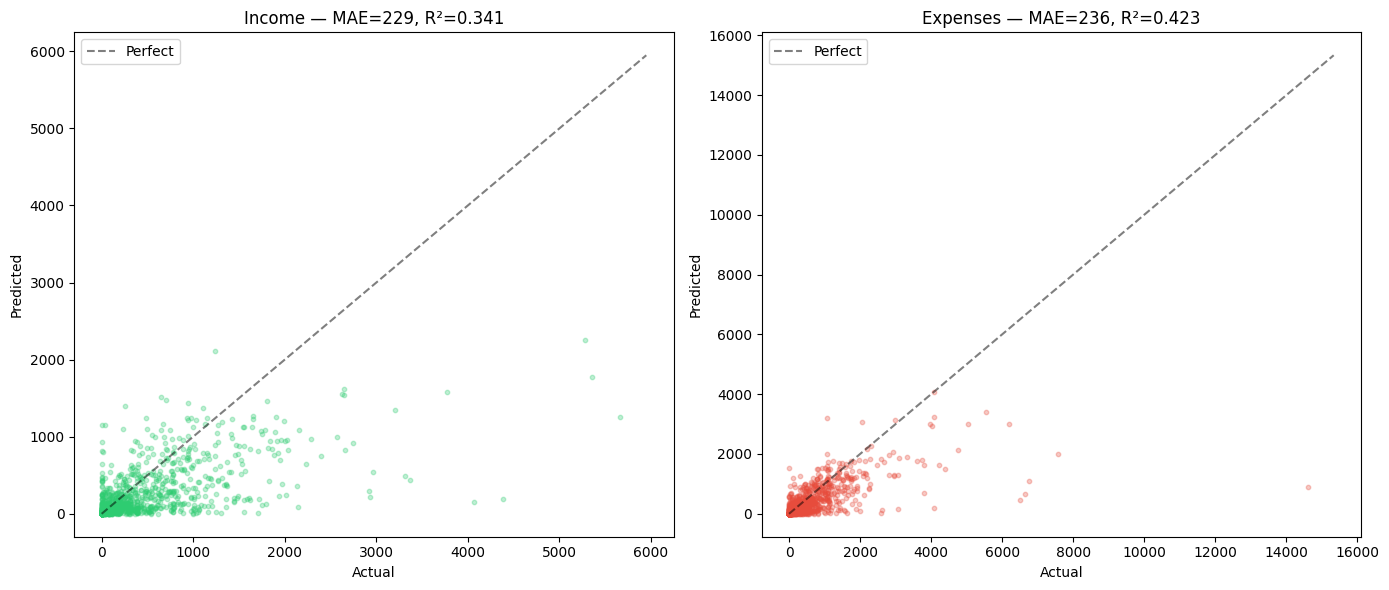

In [50]:
fig_pred_vs_actual, _axs_pva = plt.subplots(
    1, 2, figsize=(14, 6),
)
for _i, (_target, _color) in enumerate([
    ('income', '#2ecc71'),
    ('expenses', '#e74c3c'),
]):
    _ax = _axs_pva[_i]
    _true = test_results[_target]['y_true']
    _pred = test_results[_target]['y_pred']
    _ax.scatter(
        _true, _pred, alpha=0.3, s=10, color=_color,
    )
    _lim = max(_true.max(), _pred.max()) * 1.05
    _ax.plot(
        [0, _lim], [0, _lim],
        'k--', alpha=0.5, label='Perfect',
    )
    _ax.set_xlabel('Actual')
    _ax.set_ylabel('Predicted')
    _ax.set_title(
        f'{_target.title()} — '
        f'MAE={test_results[_target]["mae"]:.0f}, '
        f'R²={test_results[_target]["r2"]:.3f}'
    )
    _ax.legend()
plt.tight_layout()
plt.show()

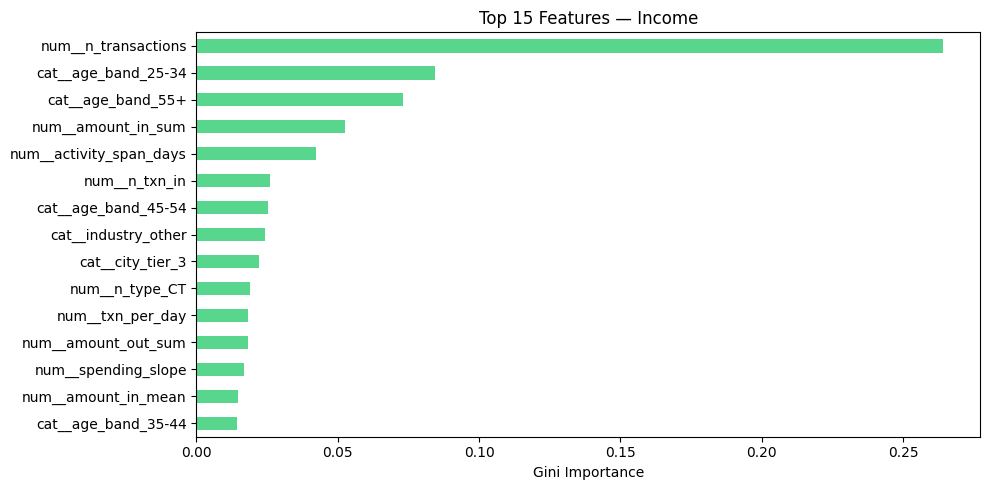

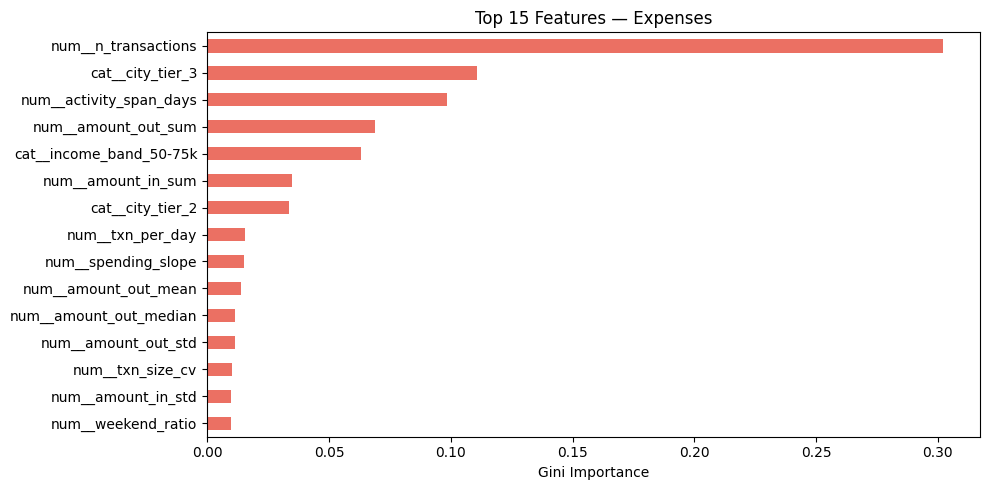

In [51]:
def get_feature_names(pipeline):
    ct = pipeline.named_steps['preprocess']
    try:
        return ct.get_feature_names_out()
    except AttributeError:
        num = ct.transformers_[0][2]
        cat = (
            ct.transformers_[1][1]
            .get_feature_names_out()
        )
        return list(num) + list(cat)

for _target in ['income', 'expenses']:
    _pipe = test_results[_target]['pipeline']
    _model = _pipe.named_steps['model']
    if not hasattr(_model, 'feature_importances_'):
        continue

    _names = get_feature_names(_pipe)
    _imp = pd.Series(
        _model.feature_importances_, index=_names,
    ).sort_values(ascending=False).head(15)

    _fig, _ax = plt.subplots(figsize=(10, 5))
    _imp.sort_values().plot.barh(
        ax=_ax,
        color='#2ecc71' if _target == 'income'
        else '#e74c3c',
        alpha=0.8,
    )
    _ax.set_title(
        f'Top 15 Features — {_target.title()}'
    )
    _ax.set_xlabel('Gini Importance')
    plt.tight_layout()
    plt.show()